In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error ,r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("../advertising.csv")
data

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [3]:
data.shape

(200, 4)

In [4]:
data.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [5]:
x = data[["TV", "Radio", "Newspaper"]]
y = data["Sales"]

In [6]:
x.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [7]:
y.head()

0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64

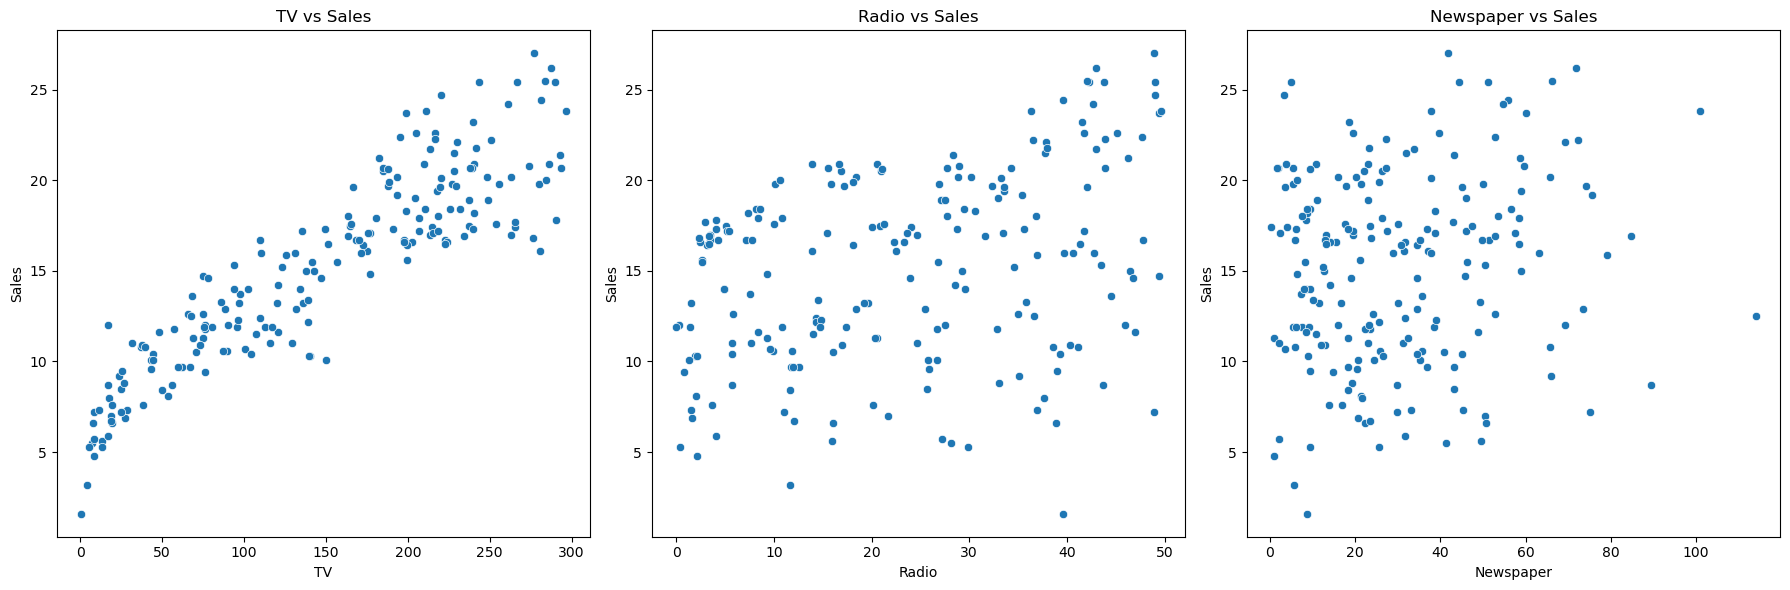

In [8]:
plt.figure(figsize=(18, 6))


plt.subplot(1, 3, 1)
sns.scatterplot(x=data["TV"], y=data["Sales"])
plt.title("TV vs Sales")
plt.xlabel("TV")
plt.ylabel("Sales")


plt.subplot(1, 3, 2)
sns.scatterplot(x=data["Radio"], y=data["Sales"])
plt.title("Radio vs Sales")
plt.xlabel("Radio")
plt.ylabel("Sales")


plt.subplot(1, 3, 3)
sns.scatterplot(x=data["Newspaper"], y=data["Sales"])
plt.title("Newspaper vs Sales")
plt.xlabel("Newspaper")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [9]:
x.corr()

,TV,Radio,Newspaper
TV,1.000000,0.054809,0.056648
Radio,0.054809,1.000000,0.354104
Newspaper,0.056648,0.354104,1.000000


                 TV     Radio  Newspaper
TV         1.000000  0.054809   0.056648
Radio      0.054809  1.000000   0.354104
Newspaper  0.056648  0.354104   1.000000


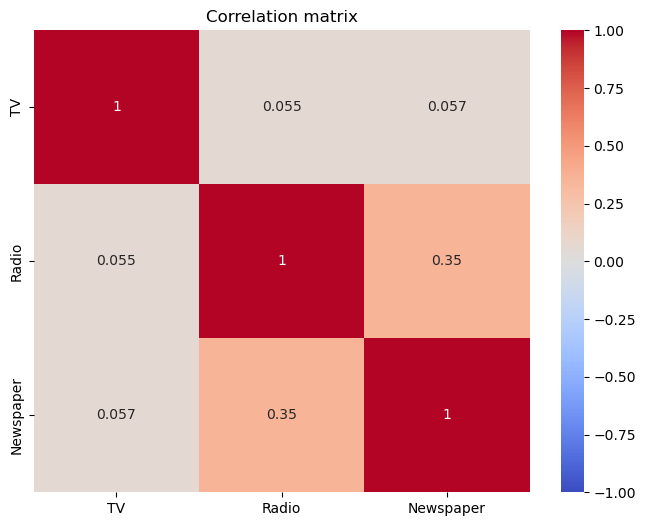

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(x.corr(), annot=True,cmap="coolwarm",vmin=-1,vmax=1)
plt.title("Correlation matrix")
print(x.corr())

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data=pd.DataFrame()
vif_data["feature"]=x.columns
vif_data["VIF"]=[variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
print(vif_data)

     feature       VIF
0         TV  2.486772
1      Radio  3.285462
2  Newspaper  3.055245


In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)


In [13]:
x_train.shape,y_train.shape

((140, 3), (140,))

In [14]:
x_test.shape,y_test.shape

((60, 3), (60,))

In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [22]:
y_test_pred = model.predict(x_test)
y_test_pred

array([17.15991908, 20.53369503, 23.68914396,  9.5191455 , 21.60736836,
       12.78101318, 21.08636345,  8.76054246, 17.11499951, 16.68789636,
        8.97584663,  8.57645026, 18.33212325,  8.17863567, 12.64605571,
       14.94486946,  8.34939536, 17.83858948, 11.12172174, 20.37740648,
       20.9483297 , 13.04035779, 11.01360656, 22.51142595,  9.40369784,
        7.98591291, 20.86943368, 13.77882255, 10.83407064,  8.00419229,
       15.88597618, 10.7027424 , 20.9521718 , 10.84679243, 21.50720813,
       21.07347295, 12.22673775, 22.85273767, 12.57698182,  6.54597206,
       11.93411853, 15.23490068, 10.07411153,  9.52159696, 17.11786382,
        7.28032677, 10.49404864, 15.24356754, 11.20742176, 11.78392665,
       14.01472163, 14.59884572, 10.82722434,  9.55839415,  9.03749681,
       12.51183313, 10.52551021, 25.01900824,  7.99334943, 15.73916263])

In [21]:
y_test.head()

95     16.9
15     22.4
30     21.4
158     7.3
128    24.7
Name: Sales, dtype: float64

In [25]:
test_result=pd.DataFrame({
    "Original Sales(Test)":y_test,
    "Predicted Sales (test)":y_test_pred
})
test_result

,Original Sales(Test),Predicted Sales (test)
95,16.9,17.159919
15,22.4,20.533695
30,21.4,23.689144
158,7.3,9.519146
128,24.7,21.607368
115,12.6,12.781013
69,22.3,21.086363
170,8.4,8.760542
174,16.5,17.115000
45,16.1,16.687896


Linear vs Non-linear

In [27]:
data=pd.read_csv("../advertising_nonlinear.csv")
data.head()

,TV,Radio,Newspaper,Sales,Sales_Nonlinear
0,230.1,37.8,69.2,22.1,5.35
1,44.5,39.3,45.1,10.4,7.20
2,17.2,45.9,69.3,12.0,7.77
3,151.5,41.3,58.5,16.5,9.82
4,180.8,10.8,58.4,17.9,5.66


In [28]:
x=data[["TV","Radio"]]
y_linear=data["Sales_Nonlinear"]

In [29]:
x.head()

,TV,Radio
0,230.1,37.8
1,44.5,39.3
2,17.2,45.9
3,151.5,41.3
4,180.8,10.8


In [30]:
y_linear.head()

0    5.35
1    7.20
2    7.77
3    9.82
4    5.66
Name: Sales_Nonlinear, dtype: float64

In [31]:
x_train,x_test,y_train,y_test=train_test_split(x,y_linear,test_size=0.2,random_state=42)

In [32]:
lin_reg=LinearRegression()
lin_reg.fit(x_train,y_train)

LinearRegression()

In [33]:
y_pred_linear=lin_reg.predict(x_test)

In [36]:
r2lin=r2_score(y_test,y_pred_linear)
r2lin

0.26852207062665845

In [40]:
rmse_lin=np.sqrt(mean_squared_error(y_test,y_pred_linear))
rmse_lin

np.float64(2.14402220837313)

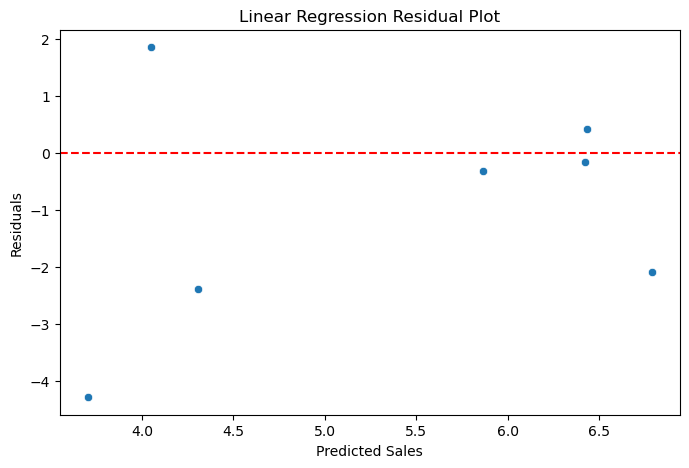

In [42]:
residuals_lin=y_test-y_pred_linear
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred_linear,y=residuals_lin)
plt.axhline(0,color="Red",linestyle="--")
plt.title("Linear Regression Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.show()


In [43]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=False)
x_poly_train=poly.fit_transform(x_train)
x_poly_test=poly.transform(x_test)

In [44]:
poly_reg=LinearRegression()
poly_reg.fit(x_poly_train,y_train)

LinearRegression()

In [46]:
y_pred_poly=poly_reg.predict(x_poly_test)
y_pred_poly

array([6.848986  , 6.55897096, 6.56428792, 1.68798077, 4.67921985,
       4.36455203, 0.44870276])

In [47]:
r2lin=r2_score(y_test,y_pred_poly)
r2lin

0.8954140097906881

In [48]:
rmse_lin=np.sqrt(mean_squared_error(y_test,y_pred_poly))
rmse_lin

np.float64(0.8107097992467884)

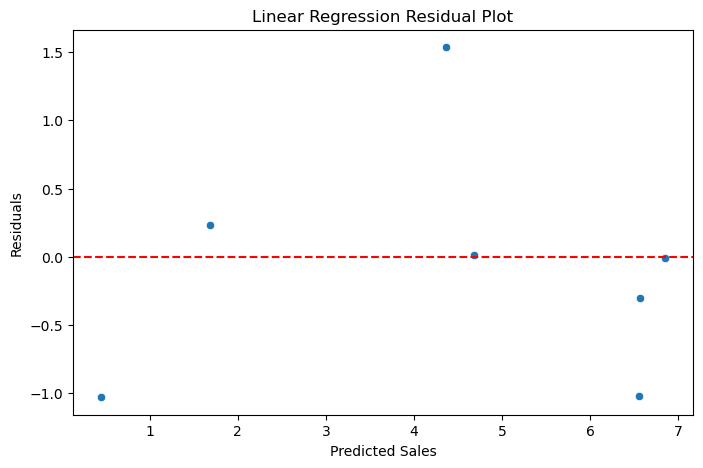

In [50]:
residuals_lin=y_test-y_pred_poly
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred_poly,y=residuals_lin)
plt.axhline(0,color="Red",linestyle="--")
plt.title("Linear Regression Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.show()
